# Chapter 22 — Average Loss Over a Dataset

Chapter 21 computed negative log loss for one next-token prediction.

This chapter repeats that calculation over many positions and averages the results.

By the end of this chapter, you should be able to:

- explain why one prediction is insufficient for model evaluation;
- build shared context-target evaluation examples;
- average per-example negative log losses;
- evaluate uniform, unigram, bigram, and trigram models;
- compare training and validation loss;
- interpret a model comparison table and plots;
- measure an exact longer-context model on matched positions; and
- explain why validation loss is more informative about generalization than training loss alone.

This chapter evaluates count-based models without training a neural network.


## From One Loss to Dataset Loss

For every context-target example, evaluation retrieves the probability assigned to the correct target and computes $-\log(p)$.

The dataset's average loss is

$$
\frac{1}{M}\sum_{i=1}^{M}-\log(p_i),
$$

where $M$ is the number of evaluated predictions and $p_i$ is the target probability for example $i$.

Average loss permits comparisons without simply rewarding a dataset for containing fewer examples.


## Training and Validation Answer Different Questions

**Training loss** measures how well a fitted model predicts data that contributed to its counts.

**Validation loss** measures predictions on held-out text that did not contribute to those counts.

A model can reduce training loss by memorizing specific patterns while failing to improve on validation text.

That gap is one sign of **overfitting**, while strong held-out performance is evidence of **generalization**.


## Build a Controlled Local Corpus

Repeated phrases make the hierarchy from uniform through trigram behavior visible in a small fixture.


In [1]:
corpus_lines = [
    "the cat sat on the mat.",
    "the cat sat on the rug.",
    "the cat slept on the mat.",
    "the dog sat on the mat.",
    "the dog ran in the yard.",
    "the dog slept on the rug.",
    "the bird sat in the tree.",
    "the bird sang in the tree.",
    "the child sat on the rug.",
    "the child ran in the yard.",
    "the cat ran in the yard.",
    "the dog ate the food.",
    "the cat ate the food.",
    "the bird ate the seed.",
    "the child ate the food.",
    "the cat looked at the dog.",
    "the small cat sat on the mat.",
    "the small dog ran in the yard.",
    "the small bird sang in the tree.",
    "the happy child sat on the rug.",
    "the happy dog slept on the mat.",
    "the dog looked at the cat.",
    "the bird looked at the child.",
    "the child looked at the bird.",
]

corpus_text = "\n".join(corpus_lines)

print(corpus_text)
print()
print("Line count:", len(corpus_lines))

the cat sat on the mat.
the cat sat on the rug.
the cat slept on the mat.
the dog sat on the mat.
the dog ran in the yard.
the dog slept on the rug.
the bird sat in the tree.
the bird sang in the tree.
the child sat on the rug.
the child ran in the yard.
the cat ran in the yard.
the dog ate the food.
the cat ate the food.
the bird ate the seed.
the child ate the food.
the cat looked at the dog.
the small cat sat on the mat.
the small dog ran in the yard.
the small bird sang in the tree.
the happy child sat on the rug.
the happy dog slept on the mat.
the dog looked at the cat.
the bird looked at the child.
the child looked at the bird.

Line count: 24


## Hold Out Validation Lines

Only the first sixteen lines fit model counts, while the final eight lines remain unseen during fitting.


In [2]:
training_lines = corpus_lines[:16]
validation_lines = corpus_lines[16:]
training_text = "\n".join(training_lines)
validation_text = "\n".join(validation_lines)

print("Training lines:", len(training_lines))
print("Validation lines:", len(validation_lines))
print("Training characters:", len(training_text))
print("Validation characters:", len(validation_text))
print()
print("Validation text:")
print(validation_text)

Training lines: 16
Validation lines: 8
Training characters: 397
Validation characters: 244

Validation text:
the small cat sat on the mat.
the small dog ran in the yard.
the small bird sang in the tree.
the happy child sat on the rug.
the happy dog slept on the mat.
the dog looked at the cat.
the bird looked at the child.
the child looked at the bird.


## Build the Vocabulary From Training Text

Validation must contain only tokens the fitted model can represent.


In [3]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: token_id for token_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        token_id: character for character, token_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    training_text
)
unknown_validation_characters = set(validation_text) - set(character_vocabulary)

print("Vocabulary size:", len(character_vocabulary))
print("Unknown validation characters:", unknown_validation_characters)
assert not unknown_validation_characters

Vocabulary size: 23
Unknown validation characters: set()


## Encode and Verify Both Splits

Exact round trips confirm that the training tokenizer preserves every evaluation token.


In [4]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    token_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        token_ids.append(character_to_id[character])
    return token_ids


def decode_character_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []
    for position, token_id in enumerate(token_ids):
        if token_id not in id_to_character:
            raise ValueError(f"Unknown token ID {token_id} at position {position}.")
        characters.append(id_to_character[token_id])
    return "".join(characters)


training_token_ids = encode_characters(training_text, character_to_id)
validation_token_ids = encode_characters(validation_text, character_to_id)

assert decode_character_ids(training_token_ids, id_to_character) == training_text
assert decode_character_ids(validation_token_ids, id_to_character) == validation_text
print("Training tokens:", len(training_token_ids))
print("Validation tokens:", len(validation_token_ids))

Training tokens: 397
Validation tokens: 244


## Define Scalar Negative Log Loss

Positive target probability produces finite loss, and higher target probability produces lower loss.


In [5]:
import math  # noqa: I001


def negative_log_loss(target_probability: float) -> float:
    if target_probability <= 0:
        raise ValueError("target_probability must be greater than 0.")
    if target_probability > 1:
        raise ValueError("target_probability cannot exceed 1.")
    loss = -math.log(target_probability)
    return 0.0 if abs(loss) < 1e-15 else loss

## Validate Every Prediction Row

Smoothing and fixed vocabulary alignment should produce nonnegative rows whose probabilities sum to one.


In [6]:
def assert_valid_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")
    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities cannot be negative.")
    if abs(sum(probabilities) - 1.0) > 1e-12:
        raise ValueError("Probabilities must sum to 1.")

## Use Identical Target Positions for Fair Comparison

The trigram model needs two previous tokens, so every core model will be scored from target position two onward.

Uniform and unigram ignore the supplied context, bigram uses its final token, and trigram uses both tokens.


In [7]:
EVALUATION_CONTEXT_LENGTH = 2


def build_evaluation_examples(
    token_ids: list[int],
    evaluation_context_length: int,
) -> tuple[list[list[int]], list[int]]:
    if evaluation_context_length < 1:
        raise ValueError("evaluation_context_length must be at least 1.")
    if evaluation_context_length >= len(token_ids):
        raise ValueError("evaluation context must be shorter than the sequence.")

    contexts = []
    targets = []
    for target_position in range(evaluation_context_length, len(token_ids)):
        contexts.append(
            token_ids[target_position - evaluation_context_length : target_position]
        )
        targets.append(token_ids[target_position])
    return contexts, targets


training_contexts, training_targets = build_evaluation_examples(
    training_token_ids,
    EVALUATION_CONTEXT_LENGTH,
)
validation_contexts, validation_targets = build_evaluation_examples(
    validation_token_ids,
    EVALUATION_CONTEXT_LENGTH,
)

print("Training examples:", len(training_contexts))
print("Validation examples:", len(validation_contexts))

Training examples: 395
Validation examples: 242


## Inspect Shared Evaluation Examples

Decoded examples expose the exact positions that every core model will score.


In [8]:
for example_number in range(8):
    context_text = decode_character_ids(
        training_contexts[example_number],
        id_to_character,
    )
    target_text = id_to_character[training_targets[example_number]]
    print(
        f"example {example_number}: context {context_text!r} → target {target_text!r}"
    )

example 0: context 'th' → target 'e'
example 1: context 'he' → target ' '
example 2: context 'e ' → target 'c'
example 3: context ' c' → target 'a'
example 4: context 'ca' → target 't'
example 5: context 'at' → target ' '
example 6: context 't ' → target 's'
example 7: context ' s' → target 'a'


## Build Smoothed Count Helpers

The unigram, bigram, and trigram models share one add-alpha smoothing strength so their nonzero target probabilities are handled consistently.


In [9]:
from collections import Counter  # noqa: I001


Context = tuple[int, ...]
ALPHA = 0.1
VOCABULARY_SIZE = len(character_vocabulary)


def count_token_ids(token_ids: list[int], vocabulary_size: int) -> list[int]:
    counts = [0 for _ in range(vocabulary_size)]
    for token_id in token_ids:
        counts[token_id] += 1
    return counts


def smooth_counts(counts: list[int], alpha: float) -> list[float]:
    if not counts:
        raise ValueError("counts cannot be empty.")
    if alpha <= 0:
        raise ValueError("alpha must be greater than 0.")
    denominator = sum(counts) + alpha * len(counts)
    probabilities = [(count + alpha) / denominator for count in counts]
    assert_valid_probability_distribution(probabilities)
    return probabilities


def build_context_counts(
    token_ids: list[int],
    context_length: int,
) -> dict[Context, Counter[int]]:
    if context_length < 1 or context_length >= len(token_ids):
        raise ValueError(
            "context_length must be positive and shorter than the sequence."
        )

    context_counts: dict[Context, Counter[int]] = {}
    for start_position in range(len(token_ids) - context_length):
        context = tuple(token_ids[start_position : start_position + context_length])
        target_id = token_ids[start_position + context_length]
        if context not in context_counts:
            context_counts[context] = Counter()
        context_counts[context][target_id] += 1
    return context_counts


def build_context_probabilities(
    context_counts: dict[Context, Counter[int]],
    vocabulary_size: int,
    alpha: float,
) -> dict[Context, list[float]]:
    return {
        context: smooth_counts(
            [target_counts[target_id] for target_id in range(vocabulary_size)],
            alpha,
        )
        for context, target_counts in context_counts.items()
    }

## Give Every Model One Prediction Interface

A protocol lets the evaluator accept any model that maps input token IDs to a probability list.


In [10]:
from typing import Protocol  # noqa: I001


class NextTokenModel(Protocol):
    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]: ...

## Model 1: Uniform Baseline

Uniform prediction ignores both training counts and context, so its loss is fixed by vocabulary size.


In [11]:
class UniformCharacterModel:
    def __init__(self, vocabulary_size: int):
        self.probabilities: list[float] = [
            1.0 / vocabulary_size for _ in range(vocabulary_size)
        ]
        assert_valid_probability_distribution(self.probabilities)

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        return self.probabilities


uniform_model = UniformCharacterModel(VOCABULARY_SIZE)

## Model 2: Unigram Frequencies

The unigram model uses smoothed overall character counts but ignores every input context.


In [12]:
class UnigramCharacterModel:
    def __init__(
        self,
        training_token_ids: list[int],
        vocabulary_size: int,
        alpha: float,
    ):
        self.probabilities: list[float] = smooth_counts(
            count_token_ids(training_token_ids, vocabulary_size),
            alpha,
        )

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        return self.probabilities


unigram_model = UnigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
)

## Model 3: Bigram Context

The bigram model selects the row for the final input token and uses unigram probabilities only if that row is unavailable.


In [13]:
class BigramCharacterModel:
    def __init__(
        self,
        training_token_ids: list[int],
        vocabulary_size: int,
        alpha: float,
        fallback_probabilities: list[float],
    ):
        self.context_probabilities: dict[Context, list[float]] = (
            build_context_probabilities(
                build_context_counts(training_token_ids, context_length=1),
                vocabulary_size,
                alpha,
            )
        )
        self.fallback_probabilities: list[float] = fallback_probabilities

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        if not input_token_ids:
            return self.fallback_probabilities
        context = (input_token_ids[-1],)
        return self.context_probabilities.get(
            context,
            self.fallback_probabilities,
        )


bigram_model = BigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
    unigram_model.probabilities,
)

## Model 4: Trigram Context With Backoff

The trigram model uses both evaluation tokens when their pair was observed and otherwise delegates to the bigram model.


In [14]:
class TrigramCharacterModel:
    def __init__(
        self,
        training_token_ids: list[int],
        vocabulary_size: int,
        alpha: float,
        bigram_model: BigramCharacterModel,
    ):
        self.context_probabilities: dict[Context, list[float]] = (
            build_context_probabilities(
                build_context_counts(training_token_ids, context_length=2),
                vocabulary_size,
                alpha,
            )
        )
        self.bigram_model: BigramCharacterModel = bigram_model

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        if len(input_token_ids) >= 2:
            context = tuple(input_token_ids[-2:])
            if context in self.context_probabilities:
                return self.context_probabilities[context]
        return self.bigram_model.predict_next_token_probabilities(input_token_ids)


trigram_model = TrigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
    bigram_model,
)

## Average the Same Evaluation Loop for Any Model

The evaluator validates each row, reads the target probability, computes loss, and returns the arithmetic mean.


In [15]:
def evaluate_average_loss(
    model: NextTokenModel,
    token_ids: list[int],
    evaluation_context_length: int,
) -> float:
    contexts, targets = build_evaluation_examples(
        token_ids,
        evaluation_context_length,
    )
    losses = []
    for context_ids, target_id in zip(contexts, targets, strict=True):
        probabilities = model.predict_next_token_probabilities(context_ids)
        assert_valid_probability_distribution(probabilities)
        losses.append(negative_log_loss(probabilities[target_id]))
    return sum(losses) / len(losses)

## Confirm the Uniform Baseline

Because every target receives the same probability, uniform training and validation loss are exactly equal under the same vocabulary.


In [16]:
uniform_training_loss = evaluate_average_loss(
    uniform_model,
    training_token_ids,
    EVALUATION_CONTEXT_LENGTH,
)
uniform_validation_loss = evaluate_average_loss(
    uniform_model,
    validation_token_ids,
    EVALUATION_CONTEXT_LENGTH,
)

print("Uniform training loss:", uniform_training_loss)
print("Uniform validation loss:", uniform_validation_loss)
print("Expected log vocabulary size:", math.log(VOCABULARY_SIZE))
assert abs(uniform_training_loss - uniform_validation_loss) < 1e-12
assert abs(uniform_training_loss - math.log(VOCABULARY_SIZE)) < 1e-12

Uniform training loss: 3.1354942159291497
Uniform validation loss: 3.1354942159291497
Expected log vocabulary size: 3.1354942159291497


## Evaluate All Four Models

The model names and objects share the same train and validation target positions.


In [17]:
from typing import NamedTuple  # noqa: I001


class EvaluationRow(NamedTuple):
    model_name: str
    training_loss: float
    validation_loss: float


models: list[tuple[str, NextTokenModel]] = [
    ("uniform", uniform_model),
    ("unigram", unigram_model),
    ("bigram", bigram_model),
    ("trigram", trigram_model),
]
evaluation_rows = []

for model_name, model in models:
    evaluation_rows.append(
        EvaluationRow(
            model_name,
            evaluate_average_loss(
                model,
                training_token_ids,
                EVALUATION_CONTEXT_LENGTH,
            ),
            evaluate_average_loss(
                model,
                validation_token_ids,
                EVALUATION_CONTEXT_LENGTH,
            ),
        )
    )

print("Model comparison")
print("-" * 50)
print("Model        | Training loss | Validation loss")
print("-" * 50)
for row in evaluation_rows:
    print(
        f"{row.model_name:<12} | {row.training_loss:>13.6f} | "
        f"{row.validation_loss:>15.6f}"
    )

Model comparison
--------------------------------------------------
Model        | Training loss | Validation loss
--------------------------------------------------
uniform      |      3.135494 |        3.135494
unigram      |      2.664511 |        2.849339
bigram       |      1.146625 |        1.616244
trigram      |      0.708225 |        1.230421


## Interpret the Measured Ranking

The next cell identifies the best held-out model and reports every training-to-validation gap instead of assuming a fixed ordering.


In [18]:
best_validation_row = min(evaluation_rows, key=lambda row: row.validation_loss)

print("Lowest validation-loss model:", best_validation_row.model_name)
print("Lowest validation loss:", best_validation_row.validation_loss)
print()
print("Training-to-validation gaps:")
for row in evaluation_rows:
    print(f"  {row.model_name:<8}: {row.validation_loss - row.training_loss:+.6f}")

Lowest validation-loss model: trigram
Lowest validation loss: 1.2304207110069314

Training-to-validation gaps:
  uniform : +0.000000
  unigram : +0.184828
  bigram  : +0.469620
  trigram : +0.522195


The measured ranking belongs to this corpus split, alpha, tokenization, and backoff design rather than being guaranteed for every dataset.


## Plot Validation Loss

The first chart compares only held-out performance, where lower bars are better.


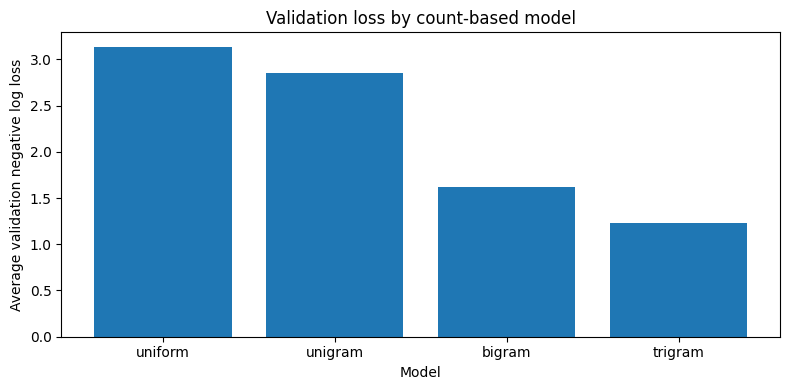

In [19]:
import matplotlib.pyplot as plt  # noqa: I001


model_names = [row.model_name for row in evaluation_rows]
validation_losses = [row.validation_loss for row in evaluation_rows]

plt.figure(figsize=(8, 4))
plt.bar(model_names, validation_losses)
plt.xlabel("Model")
plt.ylabel("Average validation negative log loss")
plt.title("Validation loss by count-based model")
plt.tight_layout()
plt.show()

## Plot Training and Validation Together

Side-by-side bars expose models whose fitted-data loss is much lower than their held-out loss.


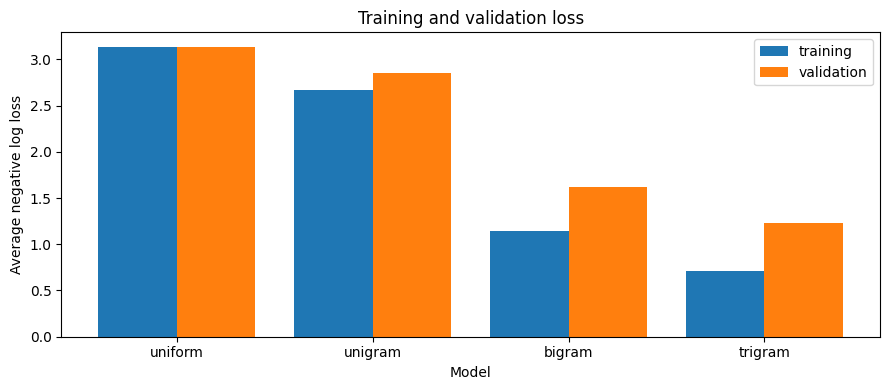

In [20]:
training_losses = [row.training_loss for row in evaluation_rows]
x_positions = list(range(len(model_names)))
bar_width = 0.4

plt.figure(figsize=(9, 4))
plt.bar(
    [position - bar_width / 2 for position in x_positions],
    training_losses,
    width=bar_width,
    label="training",
)
plt.bar(
    [position + bar_width / 2 for position in x_positions],
    validation_losses,
    width=bar_width,
    label="validation",
)
plt.xlabel("Model")
plt.ylabel("Average negative log loss")
plt.title("Training and validation loss")
plt.xticks(x_positions, model_names)
plt.legend()
plt.tight_layout()
plt.show()

## Inspect One Validation Position

Average loss repeats the same target-probability lookup shown below at every evaluation position.


In [21]:
example_index = 0
example_context = validation_contexts[example_index]
example_target = validation_targets[example_index]

print("Context:", repr(decode_character_ids(example_context, id_to_character)))
print("Target:", repr(id_to_character[example_target]))
print("-" * 61)
print("Model        | Target probability | Loss")
print("-" * 61)
for model_name, model in models:
    probabilities = model.predict_next_token_probabilities(example_context)
    target_probability = probabilities[example_target]
    print(
        f"{model_name:<12} | {target_probability:>18.6f} | "
        f"{negative_log_loss(target_probability):>10.6f}"
    )

Context: 'th'
Target: 'e'
-------------------------------------------------------------
Model        | Target probability | Loss
-------------------------------------------------------------
uniform      |           0.043478 |   3.135494
unigram      |           0.112948 |   2.180831
bigram       |           0.860590 |   0.150137
trigram      |           0.935860 |   0.066289


## Average Five Examples Manually

The small trace makes the sum-and-divide operation visible for the bigram model.


In [22]:
small_losses = []

for example_index in range(5):
    context_ids = validation_contexts[example_index]
    target_id = validation_targets[example_index]
    probabilities = bigram_model.predict_next_token_probabilities(context_ids)
    target_probability = probabilities[target_id]
    loss = negative_log_loss(target_probability)
    small_losses.append(loss)
    print(
        f"example {example_index}: "
        f"{decode_character_ids(context_ids, id_to_character)!r} → "
        f"{id_to_character[target_id]!r}, probability "
        f"{target_probability:.6f}, loss {loss:.6f}"
    )

manual_average_loss = sum(small_losses) / len(small_losses)
print("Manual five-example average:", manual_average_loss)

example 0: 'th' → 'e', probability 0.860590, loss 0.150137
example 1: 'he' → ' ', probability 0.763214, loss 0.270217
example 2: 'e ' → 's', probability 0.116220, loss 2.152273
example 3: ' s' → 'm', probability 0.008850, loss 4.727388
example 4: 'sm' → 'a', probability 0.584906, loss 0.536305
Manual five-example average: 1.5672640887852243


The full evaluator performs this identical calculation across every target position.


## Demonstrate Longer Exact Context Separately

An 8-context model must be evaluated with eight-token contexts on both splits, so it is not inserted into the shared two-token comparison table.

This separate experiment measures memorization pressure and unseen validation contexts fairly at its own required context length.


In [23]:
class FixedContextNGramModel:
    def __init__(
        self,
        training_token_ids: list[int],
        vocabulary_size: int,
        context_length: int,
        alpha: float,
        fallback_probabilities: list[float],
    ):
        self.context_length: int = context_length
        self.context_probabilities: dict[Context, list[float]] = (
            build_context_probabilities(
                build_context_counts(training_token_ids, context_length),
                vocabulary_size,
                alpha,
            )
        )
        self.fallback_probabilities: list[float] = fallback_probabilities

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        if len(input_token_ids) < self.context_length:
            return self.fallback_probabilities
        context = tuple(input_token_ids[-self.context_length :])
        return self.context_probabilities.get(
            context,
            self.fallback_probabilities,
        )


context_eight_model = FixedContextNGramModel(
    training_token_ids,
    VOCABULARY_SIZE,
    context_length=8,
    alpha=ALPHA,
    fallback_probabilities=unigram_model.probabilities,
)
context_eight_training_loss = evaluate_average_loss(
    context_eight_model,
    training_token_ids,
    evaluation_context_length=8,
)
context_eight_validation_loss = evaluate_average_loss(
    context_eight_model,
    validation_token_ids,
    evaluation_context_length=8,
)

print("8-context training loss:", context_eight_training_loss)
print("8-context validation loss:", context_eight_validation_loss)
print("Gap:", context_eight_validation_loss - context_eight_training_loss)

8-context training loss: 0.8008931108928233
8-context validation loss: 1.9148187705865407
Gap: 1.1139256596937175


## Count Unseen Eight-Token Validation Contexts

The unseen fraction reports how often the model had to discard its long exact context and use unigram fallback.


In [24]:
def unseen_context_fraction(
    model: FixedContextNGramModel,
    token_ids: list[int],
) -> float:
    contexts, targets = build_evaluation_examples(
        token_ids,
        model.context_length,
    )
    unseen_count = sum(
        tuple(context_ids) not in model.context_probabilities
        for context_ids in contexts
    )
    return unseen_count / len(contexts)


eight_context_unseen_fraction = unseen_context_fraction(
    context_eight_model,
    validation_token_ids,
)

print("Unseen validation fraction:", eight_context_unseen_fraction)

Unseen validation fraction: 0.4067796610169492


Low training loss combined with higher validation loss and frequent fallback is evidence that exact long-context fit did not transfer fully to held-out text.

The exact values depend on this fixture and should be read rather than assumed.


## Complete Evaluation Pipeline

The final cell rebuilds the core models, checks finite losses, and prints the shared comparison once more.


In [25]:
final_models: list[tuple[str, NextTokenModel]] = [
    ("uniform", UniformCharacterModel(VOCABULARY_SIZE)),
    (
        "unigram",
        UnigramCharacterModel(training_token_ids, VOCABULARY_SIZE, ALPHA),
    ),
]
final_unigram = final_models[1][1]
assert isinstance(final_unigram, UnigramCharacterModel)
final_bigram = BigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
    final_unigram.probabilities,
)
final_trigram = TrigramCharacterModel(
    training_token_ids,
    VOCABULARY_SIZE,
    ALPHA,
    final_bigram,
)
final_models.extend([("bigram", final_bigram), ("trigram", final_trigram)])

print("Model        | Training loss | Validation loss")
print("-" * 50)
for model_name, model in final_models:
    training_loss = evaluate_average_loss(
        model,
        training_token_ids,
        EVALUATION_CONTEXT_LENGTH,
    )
    validation_loss = evaluate_average_loss(
        model,
        validation_token_ids,
        EVALUATION_CONTEXT_LENGTH,
    )
    assert math.isfinite(training_loss)
    assert math.isfinite(validation_loss)
    print(f"{model_name:<12} | {training_loss:>13.6f} | {validation_loss:>15.6f}")

Model        | Training loss | Validation loss
--------------------------------------------------
uniform      |      3.135494 |        3.135494
unigram      |      2.664511 |        2.849339
bigram       |      1.146625 |        1.616244
trigram      |      0.708225 |        1.230421


## Common Mistakes

- Evaluate many positions rather than drawing conclusions from one prediction.

- Compare core models on identical target positions.

- Divide total loss by the number of evaluated examples.

- Keep validation text out of fitted counts and vocabulary estimation decisions that would leak target information.

- Do not select a model from training loss alone.

- Match evaluation context length to any model that requires a longer minimum context.

- Use smoothing and explicit fallback so held-out target probabilities remain positive and finite.


## Takeaways

Dataset evaluation computes one negative log loss per context-target pair and averages those losses.

Uniform, unigram, bigram, and trigram models can share one evaluator when they expose the same next-token probability interface and score identical targets.

Training loss measures fit to observed data, while validation loss measures prediction on held-out text and is therefore more informative about generalization.

Long exact contexts can achieve low fitted-data loss while encountering many unseen validation contexts.

The next chapter exponentiates average negative log loss to obtain perplexity, another reporting scale for the same underlying predictive performance.
